In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import joblib

In [119]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessandrolobello/agri-food-co2-emission-dataset-forecasting-ml")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\HP\.cache\kagglehub\datasets\alessandrolobello\agri-food-co2-emission-dataset-forecasting-ml\versions\1


In [120]:
df = pd.read_csv(path + "/Agrofood_co2_emission.csv")
df.head()

,Area,Year,Savanna fires,Forest fires,Crop Residues,Rice Cultivation,Drained organic soils (CO2),Pesticides Manufacturing,Food Transport,Forestland,...,Manure Management,Fires in organic soils,Fires in humid tropical forests,On-farm energy use,Rural population,Urban population,Total Population - Male,Total Population - Female,total_emission,Average Temperature °C
0,Afghanistan,1990,14.7237,0.0557,205.6077,686.00,0.0,11.807483,63.1152,-2388.803,...,319.1763,0.0,0.0,NaN,9655167.0,2593947.0,5348387.0,5346409.0,2198.963539,0.536167
1,Afghanistan,1991,14.7237,0.0557,209.4971,678.16,0.0,11.712073,61.2125,-2388.803,...,342.3079,0.0,0.0,NaN,10230490.0,2763167.0,5372959.0,5372208.0,2323.876629,0.020667
2,Afghanistan,1992,14.7237,0.0557,196.5341,686.00,0.0,11.712073,53.3170,-2388.803,...,349.1224,0.0,0.0,NaN,10995568.0,2985663.0,6028494.0,6028939.0,2356.304229,-0.259583
3,Afghanistan,1993,14.7237,0.0557,230.8175,686.00,0.0,11.712073,54.3617,-2388.803,...,352.2947,0.0,0.0,NaN,11858090.0,3237009.0,7003641.0,7000119.0,2368.470529,0.101917
4,Afghanistan,1994,14.7237,0.0557,242.0494,705.60,0.0,11.712073,53.9874,-2388.803,...,367.6784,0.0,0.0,NaN,12690115.0,3482604.0,7733458.0,7722096.0,2500.768729,0.372250


In [121]:
african_countries = [
    'Algeria','Angola','Benin','Botswana','Burkina Faso','Burundi',
    'Cabo Verde','Cameroon','Central African Republic','Chad','Comoros',
    'Congo','Democratic Republic of the Congo','Djibouti','Egypt',
    'Equatorial Guinea','Eritrea','Eswatini','Ethiopia','Ethiopia PDR',
    'Gabon','Gambia','Ghana','Guinea','Guinea-Bissau','Kenya','Lesotho',
    'Liberia','Libya','Madagascar','Malawi','Mali','Mauritania',
    'Mauritius','Morocco','Mozambique','Namibia','Niger','Nigeria',
    'Rwanda','Sao Tome and Principe','Senegal','Seychelles',
    'Sierra Leone','Somalia','South Africa','South Sudan','Sudan',
    'Sudan (former)','Togo','Tunisia','Uganda',
    'United Republic of Tanzania','Zambia','Zimbabwe','Western Sahara'
]

df_africa = df[df['Area'].isin(african_countries)]
print("Shape after filtering:", df_africa.shape)
df_africa.head()

Shape after filtering: (1649, 31)


,Area,Year,Savanna fires,Forest fires,Crop Residues,Rice Cultivation,Drained organic soils (CO2),Pesticides Manufacturing,Food Transport,Forestland,...,Manure Management,Fires in organic soils,Fires in humid tropical forests,On-farm energy use,Rural population,Urban population,Total Population - Male,Total Population - Female,total_emission,Average Temperature °C
62,Algeria,1990,55.6487,89.0459,164.2776,4.3120,0.0,104.0,1584.4410,-111.1403,...,225.2199,0.0,0.0,71.5838,12415865.0,13496502.0,12970400.0,12547674.0,22326.596965,1.005583
63,Algeria,1991,55.6487,89.0459,316.3396,4.3904,0.0,134.0,1415.6915,-111.1403,...,219.0830,0.0,0.0,80.5359,12514727.0,14039602.0,13282430.0,12851476.0,25188.715007,0.009167
64,Algeria,1992,55.6487,89.0459,291.8564,4.4688,0.0,59.0,1731.1773,-111.1403,...,225.2944,0.0,0.0,85.8921,12596547.0,14584547.0,13592789.0,13155514.0,25656.620883,-0.209083
65,Algeria,1993,55.6487,89.0459,144.9511,4.3747,0.0,51.0,1479.9805,-111.1403,...,229.7974,0.0,0.0,81.3660,12659779.0,15126480.0,13898591.0,13455737.0,26551.103455,0.499833
66,Algeria,1994,55.6487,89.0459,96.9364,4.5550,0.0,63.0,1316.1223,-111.1403,...,229.8505,0.0,0.0,76.4653,12700801.0,15661452.0,14191896.0,13745110.0,25860.094379,0.716917


In [122]:
df_africa.describe()
df_africa.info()
df_africa.isnull().sum()

<class 'pandas.DataFrame'>
Index: 1649 entries, 62 to 6964
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Area                             1649 non-null   str    
 1   Year                             1649 non-null   int64  
 2   Savanna fires                    1649 non-null   float64
 3   Forest fires                     1649 non-null   float64
 4   Crop Residues                    1557 non-null   float64
 5   Rice Cultivation                 1649 non-null   float64
 6   Drained organic soils (CO2)      1649 non-null   float64
 7   Pesticides Manufacturing         1649 non-null   float64
 8   Food Transport                   1649 non-null   float64
 9   Forestland                       1649 non-null   float64
 10  Net Forest conversion            1649 non-null   float64
 11  Food Household Consumption       1522 non-null   float64
 12  Food Retail                      16

Area                                 0
Year                                 0
Savanna fires                        0
Forest fires                         0
Crop Residues                       92
Rice Cultivation                     0
Drained organic soils (CO2)          0
Pesticides Manufacturing             0
Food Transport                       0
Forestland                           0
Net Forest conversion                0
Food Household Consumption         127
Food Retail                          0
On-farm Electricity Use              0
Food Packaging                       0
Agrifood Systems Waste Disposal      0
Food Processing                      0
Fertilizers Manufacturing            0
IPPU                                31
Manure applied to Soils             31
Manure left on Pasture               0
Manure Management                   31
Fires in organic soils               0
Fires in humid tropical forests      0
On-farm energy use                 282
Rural population         

In [123]:
df_africa = df_africa.drop(columns=['On-farm energy use'], errors='ignore')

# Drop Area because it is only an identifier
df_africa = df_africa.drop(columns=["Area"])

# Check missing values
print(df_africa.isnull().sum())

# Fill every numeric column with its median
numeric_cols = df_africa.select_dtypes(include=["number"]).columns

for col in numeric_cols:
    df_africa[col] = df_africa[col].fillna(df_africa[col].median())

# Confirm no missing values remain
print(df_africa.isnull().sum())

print("Total Missing Values:", df_africa.isnull().sum().sum())
# Confirm no missing values left
df_africa.isnull().sum()

Year                                 0
Savanna fires                        0
Forest fires                         0
Crop Residues                       92
Rice Cultivation                     0
Drained organic soils (CO2)          0
Pesticides Manufacturing             0
Food Transport                       0
Forestland                           0
Net Forest conversion                0
Food Household Consumption         127
Food Retail                          0
On-farm Electricity Use              0
Food Packaging                       0
Agrifood Systems Waste Disposal      0
Food Processing                      0
Fertilizers Manufacturing            0
IPPU                                31
Manure applied to Soils             31
Manure left on Pasture               0
Manure Management                   31
Fires in organic soils               0
Fires in humid tropical forests      0
Rural population                     0
Urban population                     0
Total Population - Male  

Year                               0
Savanna fires                      0
Forest fires                       0
Crop Residues                      0
Rice Cultivation                   0
Drained organic soils (CO2)        0
Pesticides Manufacturing           0
Food Transport                     0
Forestland                         0
Net Forest conversion              0
Food Household Consumption         0
Food Retail                        0
On-farm Electricity Use            0
Food Packaging                     0
Agrifood Systems Waste Disposal    0
Food Processing                    0
Fertilizers Manufacturing          0
IPPU                               0
Manure applied to Soils            0
Manure left on Pasture             0
Manure Management                  0
Fires in organic soils             0
Fires in humid tropical forests    0
Rural population                   0
Urban population                   0
Total Population - Male            0
Total Population - Female          0
t

In [124]:
df_africa = df_africa.apply(pd.to_numeric, errors='coerce')

In [125]:
print(df_africa.shape)
df_africa.head()

(1649, 29)


,Year,Savanna fires,Forest fires,Crop Residues,Rice Cultivation,Drained organic soils (CO2),Pesticides Manufacturing,Food Transport,Forestland,Net Forest conversion,...,Manure left on Pasture,Manure Management,Fires in organic soils,Fires in humid tropical forests,Rural population,Urban population,Total Population - Male,Total Population - Female,total_emission,Average Temperature °C
62,1990,55.6487,89.0459,164.2776,4.3120,0.0,104.0,1584.4410,-111.1403,684.9333,...,2444.0853,225.2199,0.0,0.0,12415865.0,13496502.0,12970400.0,12547674.0,22326.596965,1.005583
63,1991,55.6487,89.0459,316.3396,4.3904,0.0,134.0,1415.6915,-111.1403,684.9333,...,2350.3049,219.0830,0.0,0.0,12514727.0,14039602.0,13282430.0,12851476.0,25188.715007,0.009167
64,1992,55.6487,89.0459,291.8564,4.4688,0.0,59.0,1731.1773,-111.1403,684.9333,...,2456.1071,225.2944,0.0,0.0,12596547.0,14584547.0,13592789.0,13155514.0,25656.620883,-0.209083
65,1993,55.6487,89.0459,144.9511,4.3747,0.0,51.0,1479.9805,-111.1403,684.9333,...,2512.6051,229.7974,0.0,0.0,12659779.0,15126480.0,13898591.0,13455737.0,26551.103455,0.499833
66,1994,55.6487,89.0459,96.9364,4.5550,0.0,63.0,1316.1223,-111.1403,684.9333,...,2449.8436,229.8505,0.0,0.0,12700801.0,15661452.0,14191896.0,13745110.0,25860.094379,0.716917


In [126]:
df_africa.dtypes

Year                                 int64
Savanna fires                      float64
Forest fires                       float64
Crop Residues                      float64
Rice Cultivation                   float64
Drained organic soils (CO2)        float64
Pesticides Manufacturing           float64
Food Transport                     float64
Forestland                         float64
Net Forest conversion              float64
Food Household Consumption         float64
Food Retail                        float64
On-farm Electricity Use            float64
Food Packaging                     float64
Agrifood Systems Waste Disposal    float64
Food Processing                    float64
Fertilizers Manufacturing          float64
IPPU                               float64
Manure applied to Soils            float64
Manure left on Pasture             float64
Manure Management                  float64
Fires in organic soils             float64
Fires in humid tropical forests    float64
Rural popul

In [127]:
df_africa.isnull().sum()

Year                               0
Savanna fires                      0
Forest fires                       0
Crop Residues                      0
Rice Cultivation                   0
Drained organic soils (CO2)        0
Pesticides Manufacturing           0
Food Transport                     0
Forestland                         0
Net Forest conversion              0
Food Household Consumption         0
Food Retail                        0
On-farm Electricity Use            0
Food Packaging                     0
Agrifood Systems Waste Disposal    0
Food Processing                    0
Fertilizers Manufacturing          0
IPPU                               0
Manure applied to Soils            0
Manure left on Pasture             0
Manure Management                  0
Fires in organic soils             0
Fires in humid tropical forests    0
Rural population                   0
Urban population                   0
Total Population - Male            0
Total Population - Female          0
t

In [128]:
corr_matrix = df_africa.corr()
target_corr = corr_matrix['total_emission'].sort_values(ascending=False)

print(target_corr)

total_emission                     1.000000
Net Forest conversion              0.953176
Fires in humid tropical forests    0.762060
Forest fires                       0.728988
Savanna fires                      0.609608
Total Population - Female          0.501613
Total Population - Male            0.492842
Rural population                   0.470023
Urban population                   0.469041
Agrifood Systems Waste Disposal    0.391586
Crop Residues                      0.290279
Manure applied to Soils            0.277188
Manure Management                  0.226991
Food Retail                        0.214533
Manure left on Pasture             0.181848
Rice Cultivation                   0.169697
Food Transport                     0.163678
IPPU                               0.151521
Pesticides Manufacturing           0.124590
Drained organic soils (CO2)        0.124082
Food Processing                    0.099745
On-farm Electricity Use            0.089537
Food Household Consumption      

<Axes: xlabel='total_emission', ylabel='Count'>

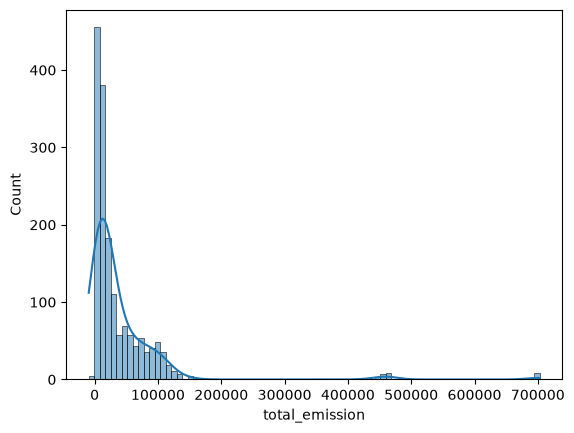

In [129]:
sns.histplot(df_africa["total_emission"], kde=True)

<Axes: xlabel='Food Processing', ylabel='total_emission'>

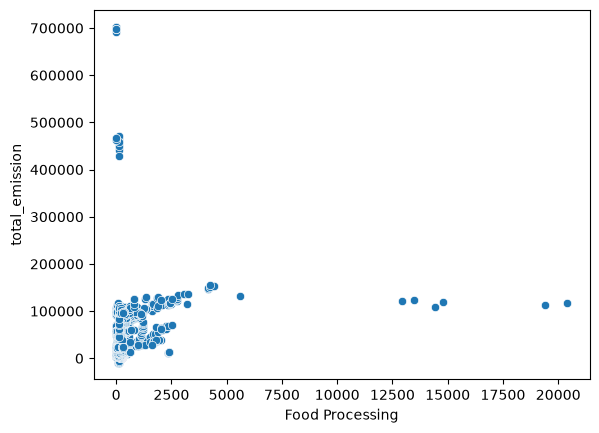

In [130]:
sns.scatterplot(
    data=df_africa,
    x="Food Processing",
    y="total_emission"
)

In [131]:
missing = df_africa.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

In [132]:
constant_cols = []

for col in df_africa.columns:
    if df_africa[col].nunique() == 1:
        constant_cols.append(col)

print(constant_cols)

['Fires in organic soils']


In [133]:
df_africa.drop(columns=constant_cols, inplace=True)

In [134]:
corr_matrix = df_africa.corr(numeric_only=True)
target_corr = corr_matrix["total_emission"].sort_values(ascending=False)
target_corr

total_emission                     1.000000
Net Forest conversion              0.953176
Fires in humid tropical forests    0.762060
Forest fires                       0.728988
Savanna fires                      0.609608
Total Population - Female          0.501613
Total Population - Male            0.492842
Rural population                   0.470023
Urban population                   0.469041
Agrifood Systems Waste Disposal    0.391586
Crop Residues                      0.290279
Manure applied to Soils            0.277188
Manure Management                  0.226991
Food Retail                        0.214533
Manure left on Pasture             0.181848
Rice Cultivation                   0.169697
Food Transport                     0.163678
IPPU                               0.151521
Pesticides Manufacturing           0.124590
Drained organic soils (CO2)        0.124082
Food Processing                    0.099745
On-farm Electricity Use            0.089537
Food Household Consumption      

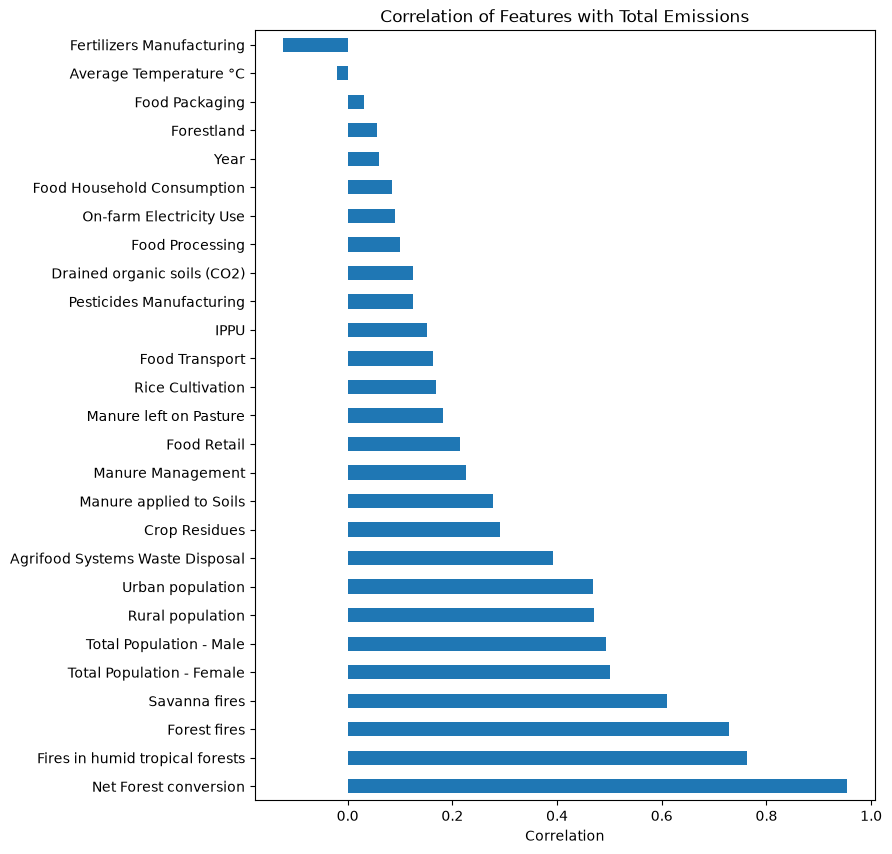

In [135]:
plt.figure(figsize=(8,10))
target_corr.drop("total_emission").plot(kind="barh")
plt.title("Correlation of Features with Total Emissions")
plt.xlabel("Correlation")
plt.show()

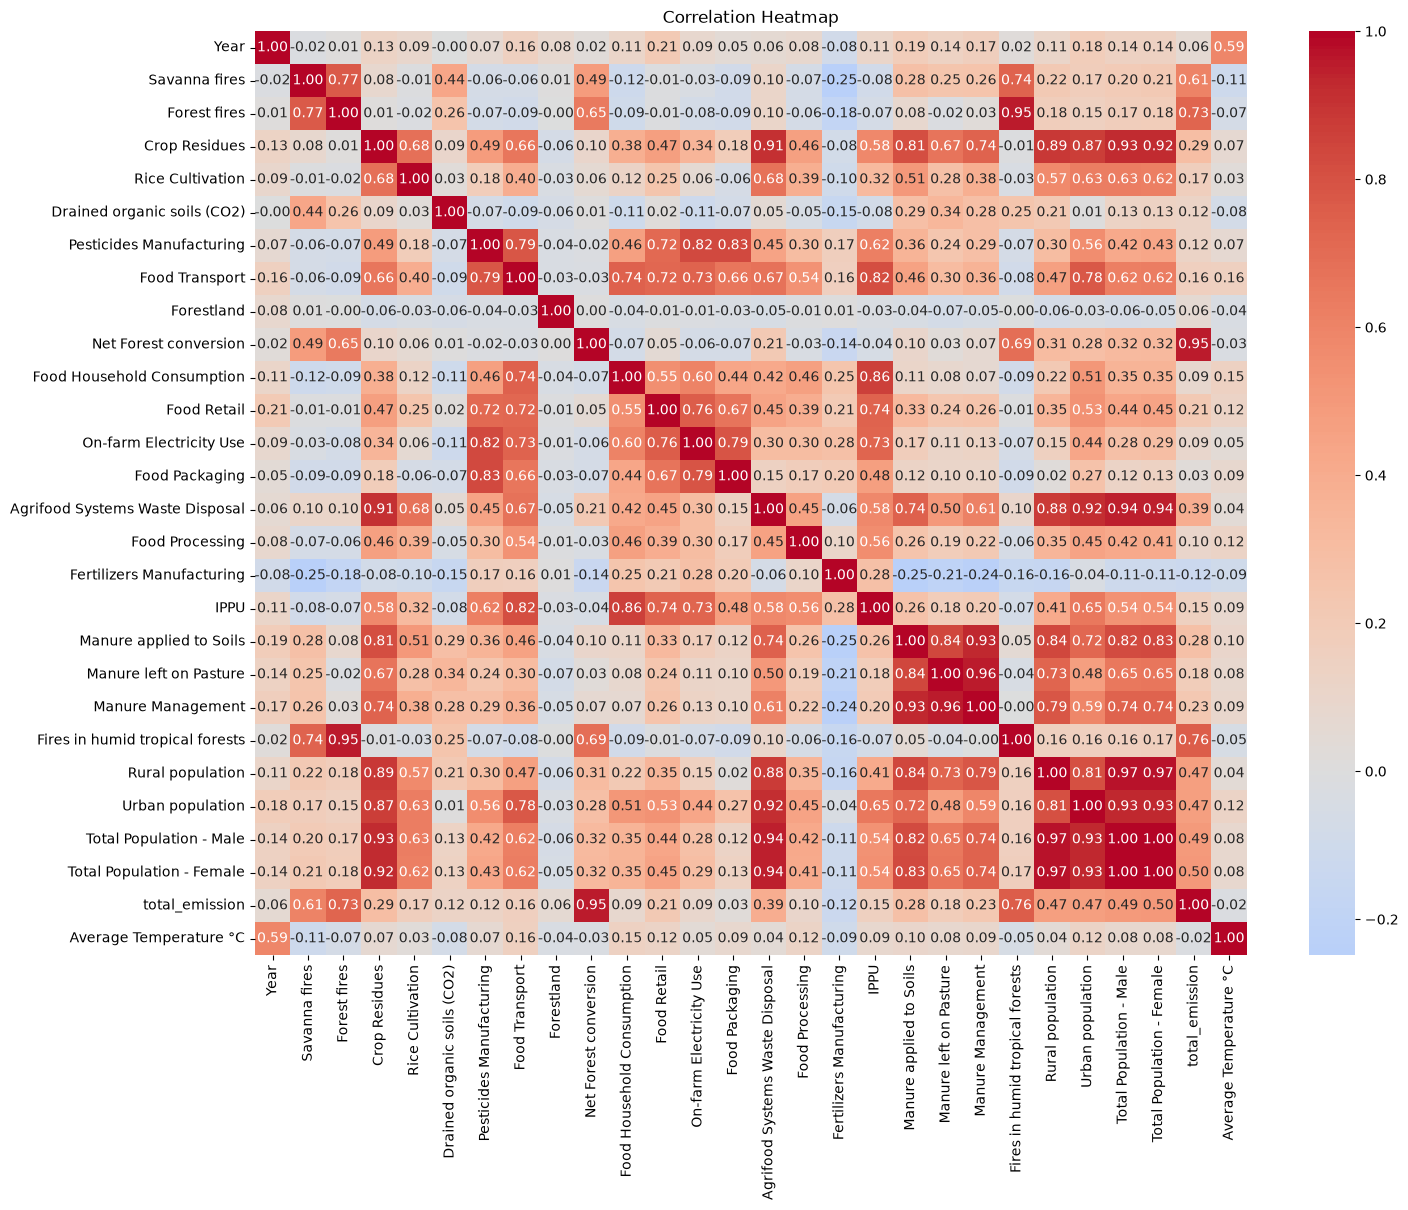

In [136]:
plt.figure(figsize=(16,12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [137]:
target = "total_emission"

selected_features = [
    "Net Forest conversion",
    "Fires in humid tropical forests",
    "Forest fires",
    "Savanna fires",
    "Agrifood Systems Waste Disposal",
    "Crop Residues",
    "Manure applied to Soils",
    "Manure Management",
    "Food Retail",
    "Rice Cultivation",
    "Food Transport",
    "Drained organic soils (CO2)",
    "Pesticides Manufacturing",
    "Food Processing",
    "On-farm Electricity Use",
    "Food Household Consumption"
]

In [138]:
df_africa.isnull().sum()
X = df_africa[selected_features]
y = df_africa[target]

In [140]:
cols_with_missing = [
    "IPPU",
    "Manure applied to Soils",
    "Manure Management"
]
for col in cols_with_missing:
    df_africa[col] = df_africa[col].fillna(df_africa[col].median())

In [141]:
X = df_africa[selected_features]
y = df_africa[target]

In [142]:
df_africa.isnull().sum()

Year                               0
Savanna fires                      0
Forest fires                       0
Crop Residues                      0
Rice Cultivation                   0
Drained organic soils (CO2)        0
Pesticides Manufacturing           0
Food Transport                     0
Forestland                         0
Net Forest conversion              0
Food Household Consumption         0
Food Retail                        0
On-farm Electricity Use            0
Food Packaging                     0
Agrifood Systems Waste Disposal    0
Food Processing                    0
Fertilizers Manufacturing          0
IPPU                               0
Manure applied to Soils            0
Manure left on Pasture             0
Manure Management                  0
Fires in humid tropical forests    0
Rural population                   0
Urban population                   0
Total Population - Male            0
Total Population - Female          0
total_emission                     0
A

In [143]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [144]:
print(X_train.isna().sum())

Net Forest conversion              0
Fires in humid tropical forests    0
Forest fires                       0
Savanna fires                      0
Agrifood Systems Waste Disposal    0
Crop Residues                      0
Manure applied to Soils            0
Manure Management                  0
Food Retail                        0
Rice Cultivation                   0
Food Transport                     0
Drained organic soils (CO2)        0
Pesticides Manufacturing           0
Food Processing                    0
On-farm Electricity Use            0
Food Household Consumption         0
dtype: int64


In [145]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (1319, 16)
Testing Features: (330, 16)
Training Target: (1319,)
Testing Target: (330,)


In [146]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled[:5])

[[ 0.02813057 -0.24947457 -0.12641313  0.10963618  0.62343235  0.29240651
   1.35728396  2.33299265 -0.03938476  1.5620882  -0.37569426  1.74291151
  -0.27624195  0.09283515 -0.32865847 -0.30543522]
 [-0.05146697 -0.29695826 -0.2682247  -0.36311115 -0.48527079 -0.47416807
  -0.37602906 -0.46254496 -0.32689096 -0.41351913 -0.4221877  -0.40975383
  -0.27954791 -0.40585984 -0.34824013 -0.30321781]
 [-0.26933485 -0.32202076 -0.35761454 -0.53458515 -0.0132663  -0.50814245
  -0.63725243 -0.64102002 -0.419501   -0.41332099 -0.4329111   0.27035405
  -0.28361908 -0.16317877 -0.34010388 -0.30379501]
 [-0.12105808 -0.32202076 -0.32031217 -0.17348862 -0.35035885 -0.29075643
  -0.12581778 -0.10914572 -0.12738332 -0.41378988 -0.17387361 -0.40975383
   0.25368308 -0.12446416  0.04044913 -0.24744145]
 [-0.29022475 -0.32202076 -0.36021811 -0.53634332 -0.03101997 -0.14781853
  -0.46027381 -0.48972202 -0.12206707 -0.09953809 -0.15436912 -0.40975383
  -0.19630748 -0.23914196 -0.12930911  0.04304737]]


In [147]:
scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)
print(scaled_df.mean().round(2))
print(scaled_df.std().round(2))

Net Forest conversion              0.0
Fires in humid tropical forests   -0.0
Forest fires                      -0.0
Savanna fires                      0.0
Agrifood Systems Waste Disposal   -0.0
Crop Residues                      0.0
Manure applied to Soils            0.0
Manure Management                 -0.0
Food Retail                        0.0
Rice Cultivation                   0.0
Food Transport                     0.0
Drained organic soils (CO2)        0.0
Pesticides Manufacturing           0.0
Food Processing                    0.0
On-farm Electricity Use            0.0
Food Household Consumption        -0.0
dtype: float64
Net Forest conversion              1.0
Fires in humid tropical forests    1.0
Forest fires                       1.0
Savanna fires                      1.0
Agrifood Systems Waste Disposal    1.0
Crop Residues                      1.0
Manure applied to Soils            1.0
Manure Management                  1.0
Food Retail                        1.0
Rice Culti

In [148]:
X = df_africa[selected_features]
y = df_africa[target]

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_predictions = lr.predict(X_test_scaled)
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Performance")
print(f"MAE : {lr_mae:.2f}")
print(f"RMSE: {lr_rmse:.2f}")
print(f"R²  : {lr_r2:.4f}")

Linear Regression Performance
MAE : 2585.72
RMSE: 3977.23
R²  : 0.9970


In [149]:
sgd = SGDRegressor(
    max_iter=1000,
    eta0=0.01,
    learning_rate="constant",
    random_state=42
)
sgd.fit(X_train_scaled, y_train)
sgd_predictions = sgd.predict(X_test_scaled)
sgd_mae = mean_absolute_error(y_test, sgd_predictions)
sgd_rmse = np.sqrt(mean_squared_error(y_test, sgd_predictions))
sgd_r2 = r2_score(y_test, sgd_predictions)

print("SGD Regressor Performance")
print(f"MAE : {sgd_mae:.2f}")
print(f"RMSE: {sgd_rmse:.2f}")
print(f"R²  : {sgd_r2:.4f}")

SGD Regressor Performance
MAE : 2876.99
RMSE: 4526.40
R²  : 0.9961


In [150]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_predictions = dt.predict(X_test)
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))
dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Performance")
print(f"MAE : {dt_mae:.2f}")
print(f"RMSE: {dt_rmse:.2f}")
print(f"R²  : {dt_r2:.4f}")

Decision Tree Performance
MAE : 1556.99
RMSE: 3490.81
R²  : 0.9977


In [151]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_predictions = rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print(f"MAE : {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²  : {rf_r2:.4f}")

Random Forest Performance
MAE : 1693.05
RMSE: 4797.17
R²  : 0.9957


In [152]:
results = {
    "Model": [
        "Linear Regression",
        "SGD Regressor",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        sgd_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        sgd_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R² Score": [
        lr_r2,
        sgd_r2,
        dt_r2,
        rf_r2
    ]
}

results_df = pd.DataFrame(results)
results_df.sort_values(by="R² Score", ascending=False)

,Model,MAE,RMSE,R² Score
2,Decision Tree,1556.987451,3490.805203,0.997708
0,Linear Regression,2585.718497,3977.227849,0.997025
1,SGD Regressor,2876.987832,4526.402862,0.996147
3,Random Forest,1693.052794,4797.165497,0.995672


In [153]:
sgd = SGDRegressor(
    max_iter=1,
    tol=None,
    random_state=42,
    learning_rate="constant",
    eta0=0.0001
)

train_loss = []
test_loss = []

epochs = 100

for epoch in range(epochs):
    sgd.partial_fit(X_train_scaled, y_train)

    train_pred = sgd.predict(X_train_scaled)
    test_pred = sgd.predict(X_test_scaled)

    train_loss.append(mean_squared_error(y_train, train_pred))
    test_loss.append(mean_squared_error(y_test, test_pred))

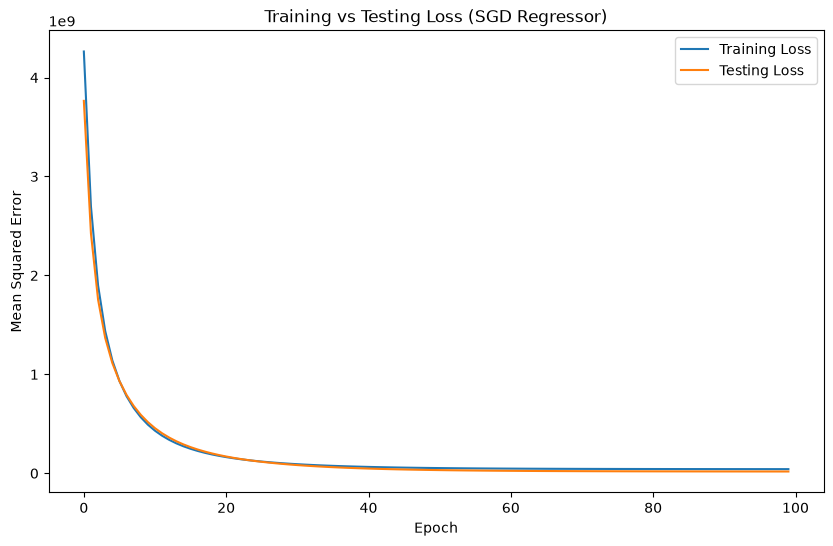

In [154]:
plt.figure(figsize=(10,6))

plt.plot(train_loss, label="Training Loss")
plt.plot(test_loss, label="Testing Loss")

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Training vs Testing Loss (SGD Regressor)")
plt.legend()

plt.show()

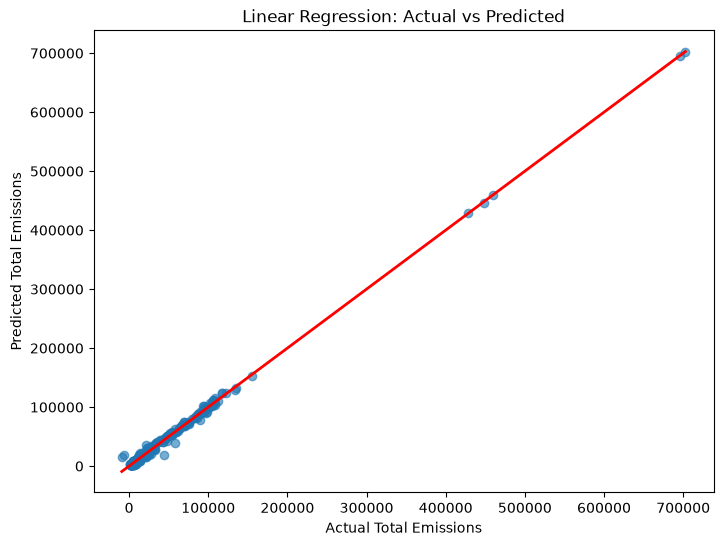

In [155]:
y_pred_lr = lr.predict(X_test_scaled)

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_lr, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)
plt.xlabel("Actual Total Emissions")
plt.ylabel("Predicted Total Emissions")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [156]:
# Identify the best model by R² score
best_model_name = results_df.sort_values(by="R² Score", ascending=False).iloc[0]["Model"]

model_lookup = {
    "Linear Regression": lr,
    "SGD Regressor": sgd_regressor if False else None,  # see note below
    "Decision Tree": dt,
    "Random Forest": rf
}

# Note: you overwrote `sgd` with the epoch-loop version later in the script,
# so re-fit or rename before this step if you want SGD eligible too.
best_model = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}[best_model_name]

print(f"Best model: {best_model_name}")

# Save model, scaler, and the exact feature list used at train time
joblib.dump(best_model, "best_model.joblib")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(selected_features, "selected_features.joblib")

print("Saved: best_model.joblib, scaler.joblib, selected_features.joblib")

Best model: Decision Tree
Saved: best_model.joblib, scaler.joblib, selected_features.joblib


In [157]:
# Models that require scaled input before predicting
SCALE_REQUIRED_MODELS = ("LinearRegression", "SGDRegressor")

def predict_emissions(input_df, model=None, scaler_obj=None, features=None):

    model = model if model is not None else best_model
    scaler_obj = scaler_obj if scaler_obj is not None else scaler
    features = features if features is not None else selected_features

    missing = [f for f in features if f not in input_df.columns]
    if missing:
        raise ValueError(f"Input data is missing required columns: {missing}")

    X_new = input_df[features]

    model_name = type(model).__name__
    if model_name in SCALE_REQUIRED_MODELS:
        X_new = scaler_obj.transform(X_new)

    predictions = model.predict(X_new)

    output_df = input_df.copy()
    output_df["predicted_total_emission"] = predictions
    return output_df